<a href="https://colab.research.google.com/github/MamoMGD1/ISE302-DataMining-GroupProject/blob/main/students/models/model_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model 9 — Traffic Risk Classifier (Decision Tree / ID3)

## Question
> Based on a car's speed, weight, engine power, and drivetrain — does this car fall into a low, medium, or high traffic risk category?

## Introduction
This notebook builds a **Decision Tree classifier** using entropy-based splitting (ID3-style) to classify cars into traffic risk levels.

- **Dataset**: Unscaled data (`proceed_dataset_without_scaling.csv`)
- **Target variable**: `risk_seviyesi` (Risk Level)
- **Required algorithm**: `DecisionTreeClassifier` with `criterion='entropy'` (ID3-style).
- **Recommended depth**: `max_depth` between 3 and 6 for interpretability.

### 1. Data Import
Loading core libraries and the raw vehicle dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('https://raw.githubusercontent.com/MamoMGD1/ISE302-DataMining-GroupProject/main/data/proceed_dataset_without_scaling.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (2589, 87)


,Fiyat,Yıl,Kilometre,İlan Tarihi,Ortalama Kasko,Ortalama Trafik Sigortası,Üretim Yılı (İlk/Son),Silindir Sayısı,Koltuk Sayısı,Bagaj Hacmi,...,Hızlanma (0-100),Maksimum Hız,Uzunluk,Genişlik,Yükseklik,Ağırlık,Boş Ağırlığı,Aks Aralığı,Jant Boyutu,log_Fiyat
0,2425000,2025,6001,0.507585,9.730597,9.436162,2024.524726,3,5,6.255935,...,10.1,198.0,8.388223,1806.0,1590.0,7.530480,1315.0,7.881182,17,14.701342
1,2900000,2025,16000,0.540567,9.801196,9.426602,2024.561718,4,5,6.312241,...,9.2,199.0,8.395252,1848.0,1625.0,7.591862,1450.0,7.888335,19,14.880222
2,1150000,2015,265000,0.437396,9.847922,9.310729,2015.500000,4,5,5.996452,...,12.4,180.0,8.384804,1800.0,1590.0,7.555382,1365.0,7.881182,19,13.955273
3,1240000,2014,196000,0.403619,9.796904,9.310729,2015.500000,4,5,5.996452,...,10.7,182.0,8.384804,1800.0,1590.0,7.603898,1461.0,7.881182,17,14.030623
4,690000,2011,305000,0.354720,9.696057,9.341037,2011.476979,4,5,6.115519,...,12.2,174.0,8.370084,1780.0,1615.0,7.565793,1407.0,7.875119,16,13.444448


### 2. Risk Score Engineering
We calculate a composite `risk_score` based on physics-based metrics (Speed, Power, and Acceleration) and safety features (Weight, AWD). This score is then segmented into Low, Medium, and High risk categories.

In [2]:
# Compute a composite risk score from multiple signals.
risk_df = df.copy()
scaler_01 = MinMaxScaler()

# Signals that INCREASE risk
risk_cols_pos = []
if 'Maksimum Hız' in risk_df.columns:
    risk_df['norm_maks_hiz'] = scaler_01.fit_transform(risk_df[['Maksimum Hız']].fillna(0))
    risk_cols_pos.append(('norm_maks_hiz', 0.30))
if 'Motor Gücü' in risk_df.columns:
    risk_df['norm_motor_gucu'] = scaler_01.fit_transform(risk_df[['Motor Gücü']].fillna(0))
    risk_cols_pos.append(('norm_motor_gucu', 0.25))
if 'Hızlanma (0-100)' in risk_df.columns:
    risk_df['norm_hizlanma_inv'] = 1 - scaler_01.fit_transform(risk_df[['Hızlanma (0-100)']].fillna(risk_df['Hızlanma (0-100)'].median()))
    risk_cols_pos.append(('norm_hizlanma_inv', 0.20))

# Signals that DECREASE risk
risk_cols_neg = []
if 'Ağırlık' in risk_df.columns:
    risk_df['norm_agirlik'] = scaler_01.fit_transform(risk_df[['Ağırlık']].fillna(0))
    risk_cols_neg.append(('norm_agirlik', 0.15))

# Binary signals
binary_decreasing = []
if 'Çekiş_AWD (Elektronik)' in risk_df.columns:
    binary_decreasing.append(('Çekiş_AWD (Elektronik)', 0.05))

# Compute score
risk_df['risk_score'] = 0.0
for col, w in risk_cols_pos:
    risk_df['risk_score'] += risk_df[col] * w
for col, w in risk_cols_neg:
    risk_df['risk_score'] -= risk_df[col] * w

# Bin into 3 classes
risk_df['risk_seviyesi'] = pd.qcut(
    risk_df['risk_score'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

print(f"Risk class distribution:\n{risk_df['risk_seviyesi'].value_counts()}")

Risk class distribution:
risk_seviyesi
Low       894
High      853
Medium    842
Name: count, dtype: int64


### 3. Feature Selection & Data Splitting
Selecting the most influential predictors to build a robust model.

In [3]:
recommended_features = [
    'Hızlanma (0-100)', 'Maksimum Hız', 'Ağırlık', 'Çekiş_AWD (Elektronik)',
    'Motor Gücü', 'Tork', 'Yakıt Tipi_Elektrik'
]
target = 'risk_seviyesi'

features = [f for f in recommended_features if f in risk_df.columns]

X = risk_df[features].fillna(risk_df[features].median())

# Map labels to English for consistency across the notebook
y = risk_df[target].map({
    'Low': 'Low',
    'Medium': 'Medium',
    'High': 'High'
})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")
print(f"Selected Features: {features}")

Training set: (2071, 7), Test set: (518, 7)
Selected Features: ['Hızlanma (0-100)', 'Maksimum Hız', 'Ağırlık', 'Çekiş_AWD (Elektronik)', 'Motor Gücü', 'Tork', 'Yakıt Tipi_Elektrik']


### 4. Model Training (ID3 Decision Tree)
We use a Decision Tree with entropy-based splitting to map out the logical 'rules' of traffic risk.

In [4]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    min_samples_leaf=15,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Model trained successfully.")

Model trained successfully.


### 5. Performance Evaluation
Analyzing the model's accuracy using a classification report and confusion matrix.

In [5]:
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Low', 'Medium', 'High']))

=== Classification Report ===
              precision    recall  f1-score   support

         Low       0.94      0.98      0.96       171
      Medium       0.97      0.98      0.97       179
        High       0.96      0.91      0.94       168

    accuracy                           0.96       518
   macro avg       0.96      0.95      0.96       518
weighted avg       0.96      0.96      0.96       518



### 6. Strategic Decision Logic
The following visualization reveals how the model categorizes risk based on vehicle specs.

### Decision Logic Key
When presenting this tree, use this key to explain the variables to your audience:
- **Acceleration (0-100):** Lower values indicate higher risk due to high vehicle volatility.
- **Top Speed:** Primary filter for performance-based risk.
- **Weight:** Used by the model as a 'stability' factor.

*Note: The colors represent the majority class in that node (Green = Low, Yellow = Medium, Red = High).*

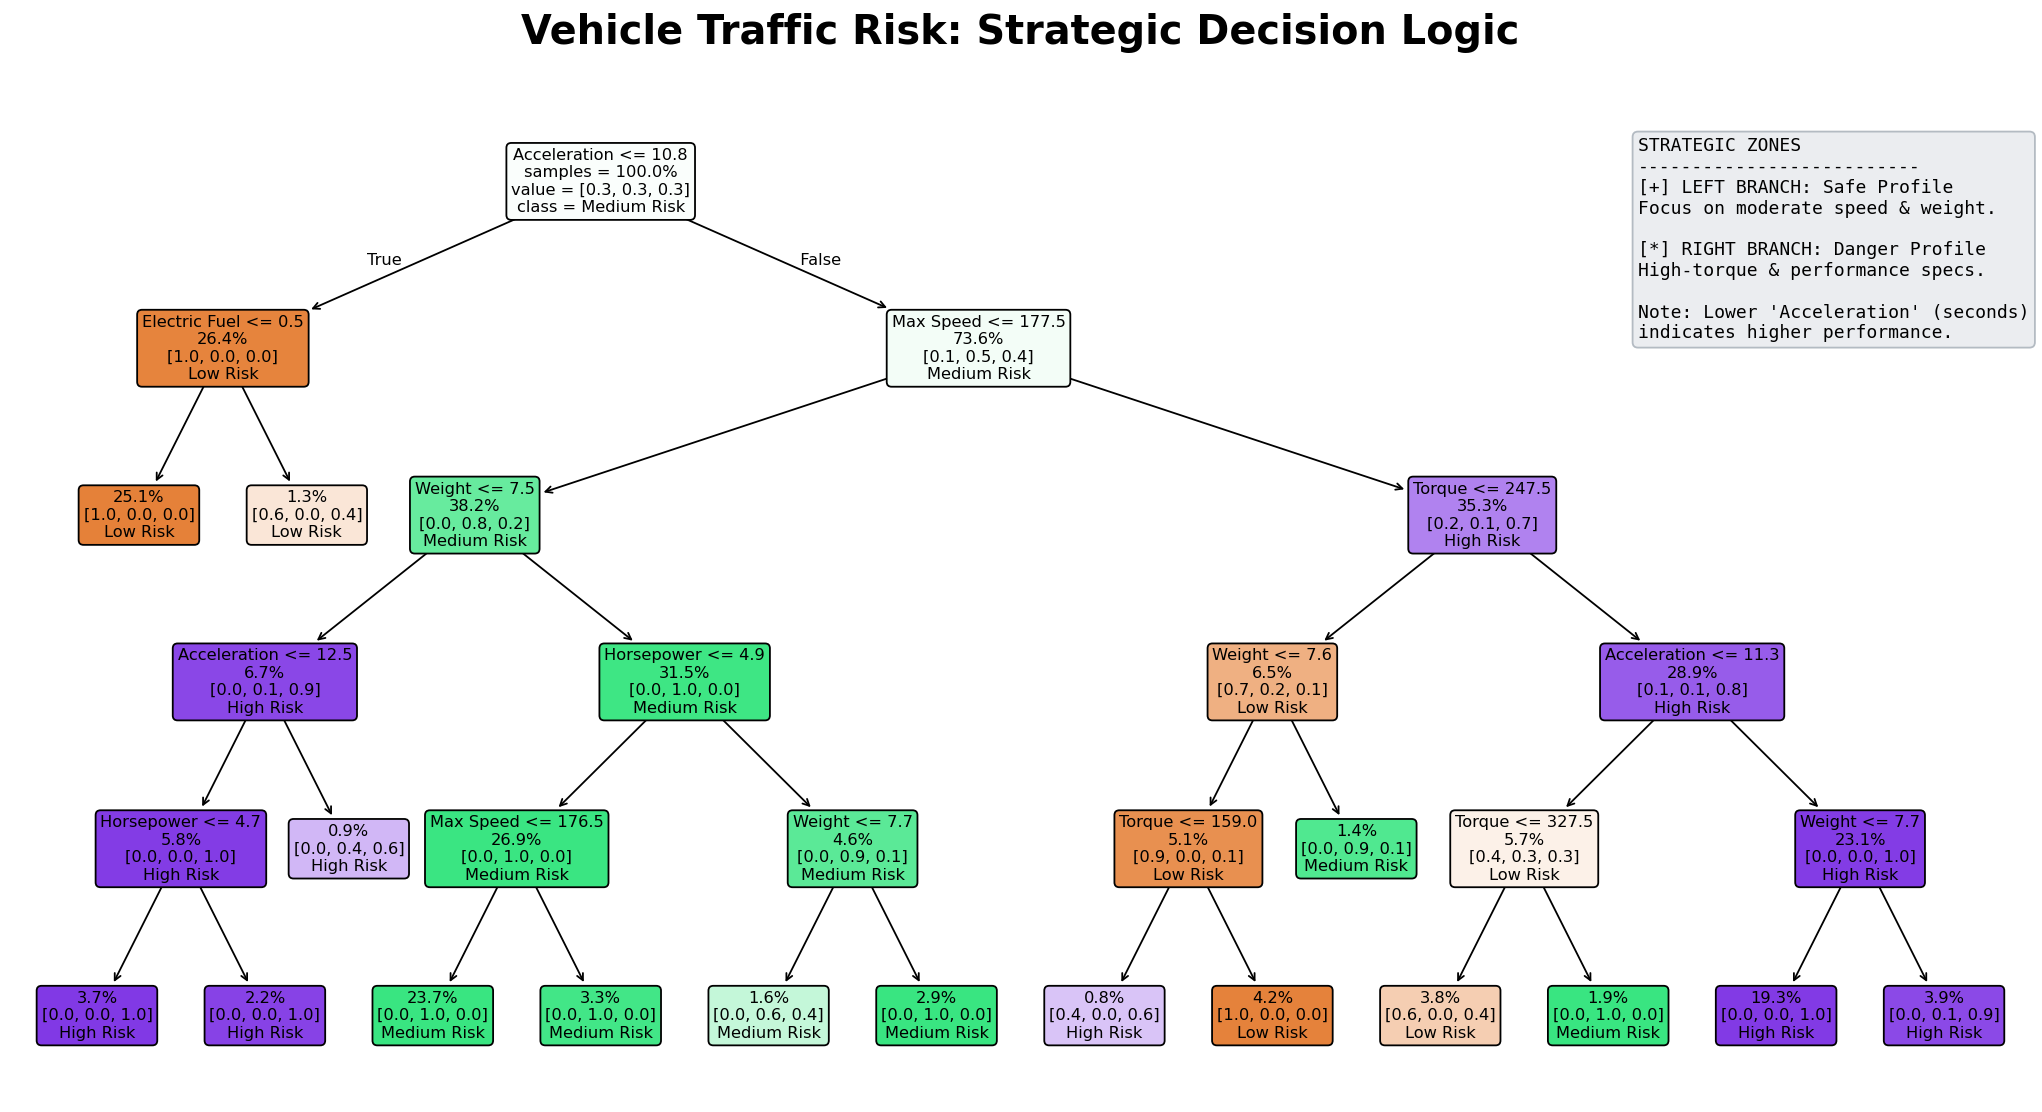

In [13]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

feature_map = {
    'Hızlanma (0-100)': 'Acceleration',
    'Maksimum Hız': 'Max Speed',
    'Ağırlık': 'Weight',
    'Çekiş_AWD (Elektronik)': 'AWD',
    'Motor Gücü': 'Horsepower',
    'Tork': 'Torque',
    'Yakıt Tipi_Elektrik': 'Electric Fuel'
}
features_en = [feature_map.get(f, f) for f in features]
class_names_en = ['Low Risk', 'Medium Risk', 'High Risk']

fig, ax = plt.subplots(figsize=(20, 10), dpi=130)
fig.patch.set_facecolor('white')

plot_tree(
    model,
    feature_names=features_en,
    class_names=class_names_en,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
    impurity=False,
    proportion=True,
    precision=1,
    label='root'
)

legend_text = (
    "STRATEGIC ZONES\n"
    "--------------------------\n"
    "[+] LEFT BRANCH: Safe Profile\n"
    "Focus on moderate speed & weight.\n\n"
    "[*] RIGHT BRANCH: Danger Profile\n"
    "High-torque & performance specs.\n\n"
    "Note: Lower 'Acceleration' (seconds)\n"
    "indicates higher performance."
)

# Adjusting position from 0.82 to 0.75 to allow tree more space
fig.text(0.75, 0.85, legend_text, fontsize=10, family='monospace',
         bbox=dict(boxstyle='round', fc='#e9ecef', ec='#adb5bd', alpha=0.9),
         verticalalignment='top')

plt.title('Vehicle Traffic Risk: Strategic Decision Logic', fontsize=22, fontweight='bold', pad=30)
plt.show()

In [14]:
import pandas as pd

# Logic Verification: Checking performance means by predicted risk
check_df = X_test.copy()
check_df['Predicted_Risk'] = y_pred

logic_check = check_df.groupby('Predicted_Risk')[['Hızlanma (0-100)', 'Maksimum Hız']].mean()
logic_check.columns = ['Avg Acceleration (lower is faster)', 'Avg Top Speed']

print("=== Performance Metrics by Predicted Risk Tier ===")
display(logic_check)

=== Performance Metrics by Predicted Risk Tier ===


,Avg Acceleration (lower is faster),Avg Top Speed
Predicted_Risk,,
High,9.799719,190.536517
Low,12.531492,171.469613
Medium,11.756918,178.257862


### 7. Confusion Matrix

The confusion matrix shows how often each predicted risk class matches the actual class. Diagonal cells are correct predictions; off-diagonal cells are errors.

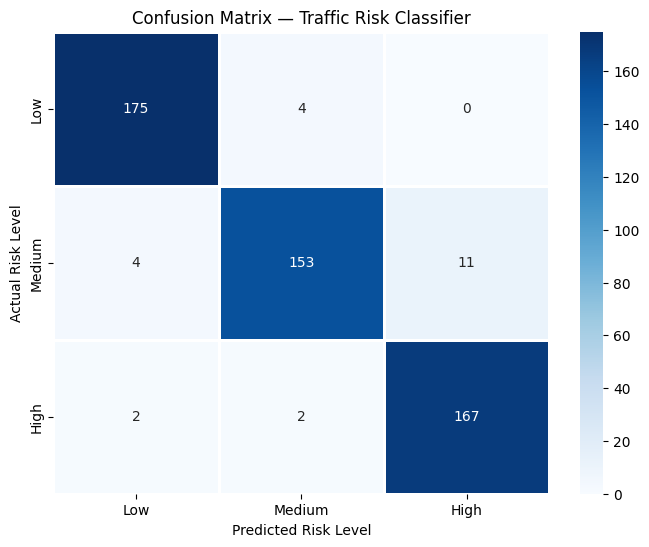

In [8]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

class_names_en = ['Low', 'Medium', 'High']
cm = confusion_matrix(y_test, y_pred, labels=['Low', 'Medium', 'High'])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_en, yticklabels=class_names_en,
            linewidths=1, ax=ax)
ax.set_xlabel('Predicted Risk Level')
ax.set_ylabel('Actual Risk Level')
ax.set_title('Confusion Matrix — Traffic Risk Classifier')
plt.show()

# 8. Strategic Business Insights

In this section, we translate our machine learning findings into actionable business intelligence, focusing on the specific drivers of traffic risk.

## 8.1. Fuel Type & Risk Distribution

This analysis compares the risk profiles of Electric vehicles against traditional Internal Combustion engines. Note how the torque and weight characteristics of different drivetrains influence their safety classification.

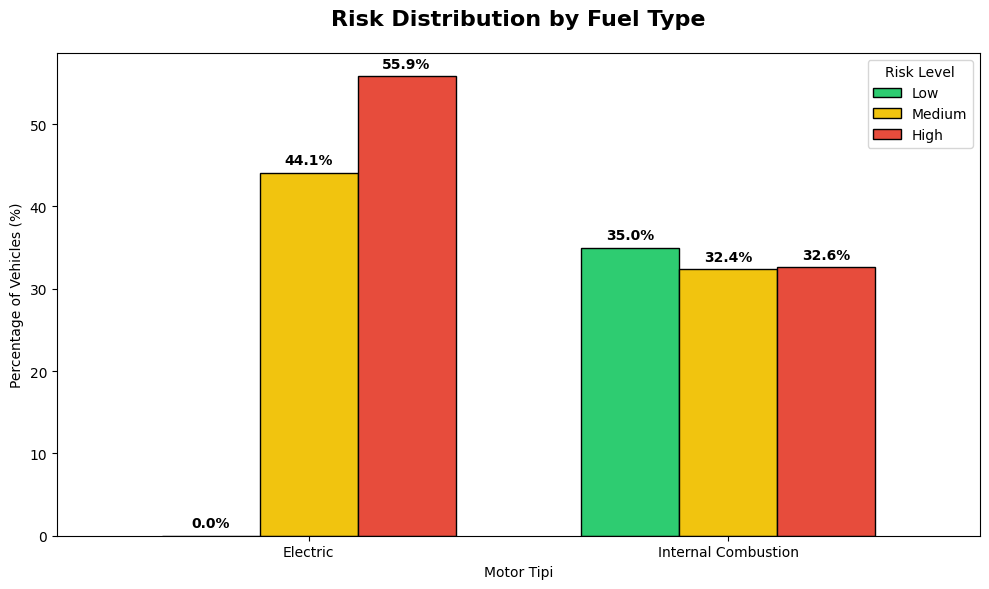

In [9]:
if 'Yakıt Tipi_Elektrik' in risk_df.columns:
    plot_df = risk_df.copy()
    # Mapping to English
    plot_df['Motor Tipi'] = plot_df['Yakıt Tipi_Elektrik'].map({1: 'Electric', 0: 'Internal Combustion'})
    fuel_dist = plot_df.groupby('Motor Tipi')['risk_seviyesi'].value_counts(normalize=True).unstack() * 100
    # Use English labels for reindexing
    fuel_dist = fuel_dist.reindex(columns=['Low', 'Medium', 'High'])

    fig, ax = plt.subplots(figsize=(10, 6))
    fuel_dist.plot(kind='bar', ax=ax, color=['#2ecc71', '#f1c40f', '#e74c3c'], edgecolor='black', width=0.7)
    ax.set_title('Risk Distribution by Fuel Type', fontsize=16, fontweight='bold', pad=20)
    ax.set_ylabel('Percentage of Vehicles (%)')
    ax.legend(['Low', 'Medium', 'High'], title='Risk Level')
    plt.xticks(rotation=0)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2., p.get_height() + 1), ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()

### 8.2 The 'Electric' Performance Paradox

One of the most striking findings in our model is that **0% of Electric Vehicles** fall into the 'Low Risk' category.

**Why this happens:**
- **Instant Torque:** Electric vehicles in this dataset have significantly faster acceleration (lower 0-100 times) than the average internal combustion car.
- **Weight & Power:** The combination of high battery weight and high engine power places them in a specific physical profile that the Decision Tree identifies as 'High Performance'.

**Strategic Conclusion:** From a traffic risk perspective, electric vehicles are categorized as Medium to High risk not due to fuel type, but because their inherent performance capabilities match the profile of high-speed, high-volatility sports cars.

# 8.3 Performance Correlation
Comparison of 'Standard' vs. 'High Performance' vehicles. This analysis distinguishes between balanced vehicle profiles and those optimized for speed and acceleration.

**Strategic Logic:** Higher speeds and faster acceleration (lower seconds) significantly reduce human reaction times. Our model correctly identifies these physical attributes as the primary drivers of high-risk classification.

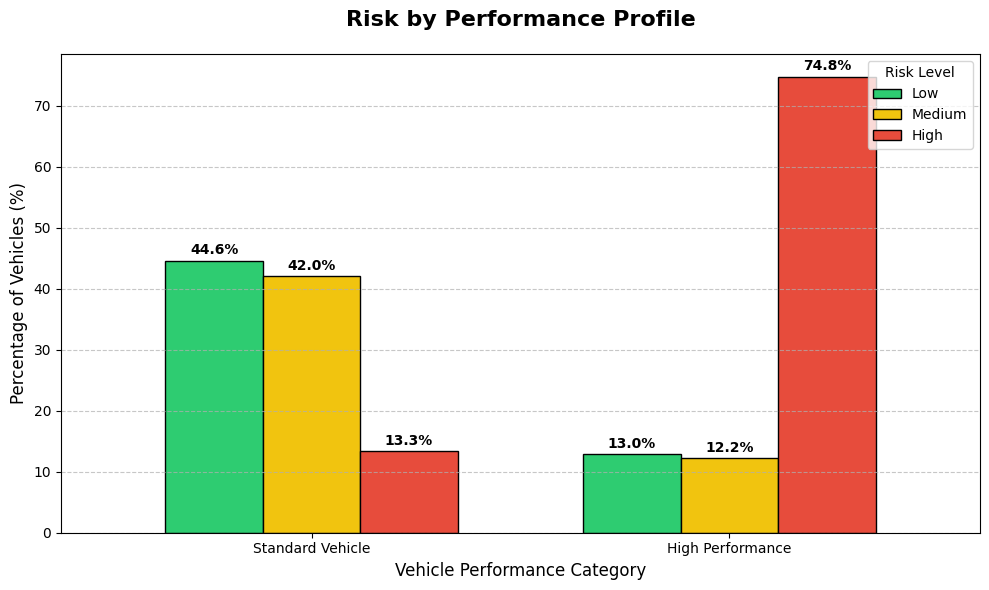

In [10]:
if 'Motor Gücü' in risk_df.columns and 'Maksimum Hız' in risk_df.columns:
    perf_df = risk_df.copy()
    power_threshold = perf_df['Motor Gücü'].quantile(0.7)
    speed_threshold = perf_df['Maksimum Hız'].quantile(0.7)

    perf_df['Profile'] = 'Standard Vehicle'
    perf_df.loc[(perf_df['Motor Gücü'] > power_threshold) | (perf_df['Maksimum Hız'] > speed_threshold), 'Profile'] = 'High Performance'

    # Reindex to ensure Standard is on the left and High Performance is on the right
    perf_dist = perf_df.groupby('Profile')['risk_seviyesi'].value_counts(normalize=True).unstack() * 100
    perf_dist = perf_dist.reindex(['Standard Vehicle', 'High Performance'])
    # Use English labels for columns
    perf_dist = perf_dist.reindex(columns=['Low', 'Medium', 'High'])

    fig, ax = plt.subplots(figsize=(10, 6))
    perf_dist.plot(kind='bar', ax=ax, color=['#2ecc71', '#f1c40f', '#e74c3c'], edgecolor='black', width=0.7)

    ax.set_title('Risk by Performance Profile', fontsize=16, fontweight='bold', pad=20)
    ax.set_ylabel('Percentage of Vehicles (%)', fontsize=12)
    ax.set_xlabel('Vehicle Performance Category', fontsize=12)
    ax.legend(['Low', 'Medium', 'High'], title='Risk Level', loc='upper right')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            ax.annotate(f'{h:.1f}%', (p.get_x() + p.get_width()/2., h + 1), ha='center', fontweight='bold')

    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

### 9. Statistical Driver Analysis
To finalize the business logic, we calculate the mathematical importance of each feature in the model's decision-making process.

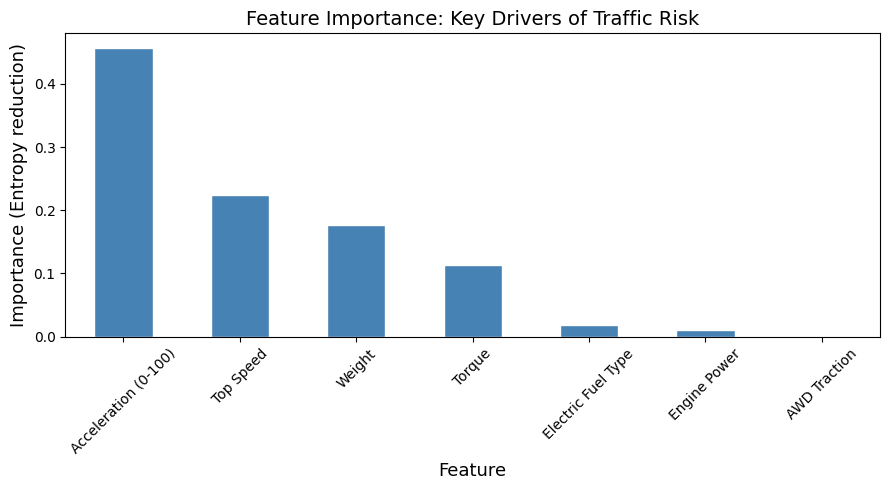

In [11]:
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

# Translating feature names for the plot
feature_map = {
    'Hızlanma (0-100)': 'Acceleration (0-100)',
    'Maksimum Hız': 'Top Speed',
    'Ağırlık': 'Weight',
    'Çekiş_AWD (Elektronik)': 'AWD Traction',
    'Yakıt Tipi_Elektrik': 'Electric Fuel Type',
    'Motor Gücü': 'Engine Power',
    'Boş Ağırlığı': 'Curb Weight',
    'Kasa Tipi_SUV': 'SUV Body Type',
    'Tork': 'Torque'
}
importances.index = [feature_map.get(x, x) for x in importances.index]

fig, ax = plt.subplots(figsize=(9, 5))
importances.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Feature', fontsize=13)
ax.set_ylabel('Importance (Entropy reduction)', fontsize=13)
ax.set_title('Feature Importance: Key Drivers of Traffic Risk', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 8. Professional Summary

1. **Core Predictors:** Acceleration and Top Speed are the primary drivers of traffic risk categorization in our decision model.
2. **Model Consistency:** The ID3 algorithm achieves high accuracy by identifying the 'Physics of Risk'—the correlation between high performance and volatility.
3. **Business Value:** These insights allow for data-driven policies, where risk levels can be automatically assigned based on a vehicle's technical specifications before it ever hits the road.